# Plot Zero-Variance extrapolation - 1D chain L = 20

In [34]:
import glob
import os
import sys

In [35]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.plot.plotlib import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
verbose = True

In [37]:
# Settings
L = 20                                              # Length of the Markov chain
N_sim = 1000000                                     # Number of Monte Carlo simulations

## Alpha optimization

In [38]:
dossiers = glob.glob("../../datas/2D_4x4/datas_alpha_iter_*") 

Loading and processing 3 folders...
✅ Loading complete: 3 simulations processed!
Generating 1000000 synthetic linear regressions...

========== GLOBAL MONTE CARLO RESULTS ==========
Points used for fit       : 6 (3 simulations)
Exact Energy              : -0.56142416
Extrapolated Energy       : -0.56121341 ± 0.00023160
95% Confidence Interval   : [-0.56167926 , -0.56076108]
Absolute Error vs Exact   : 2.11e-04


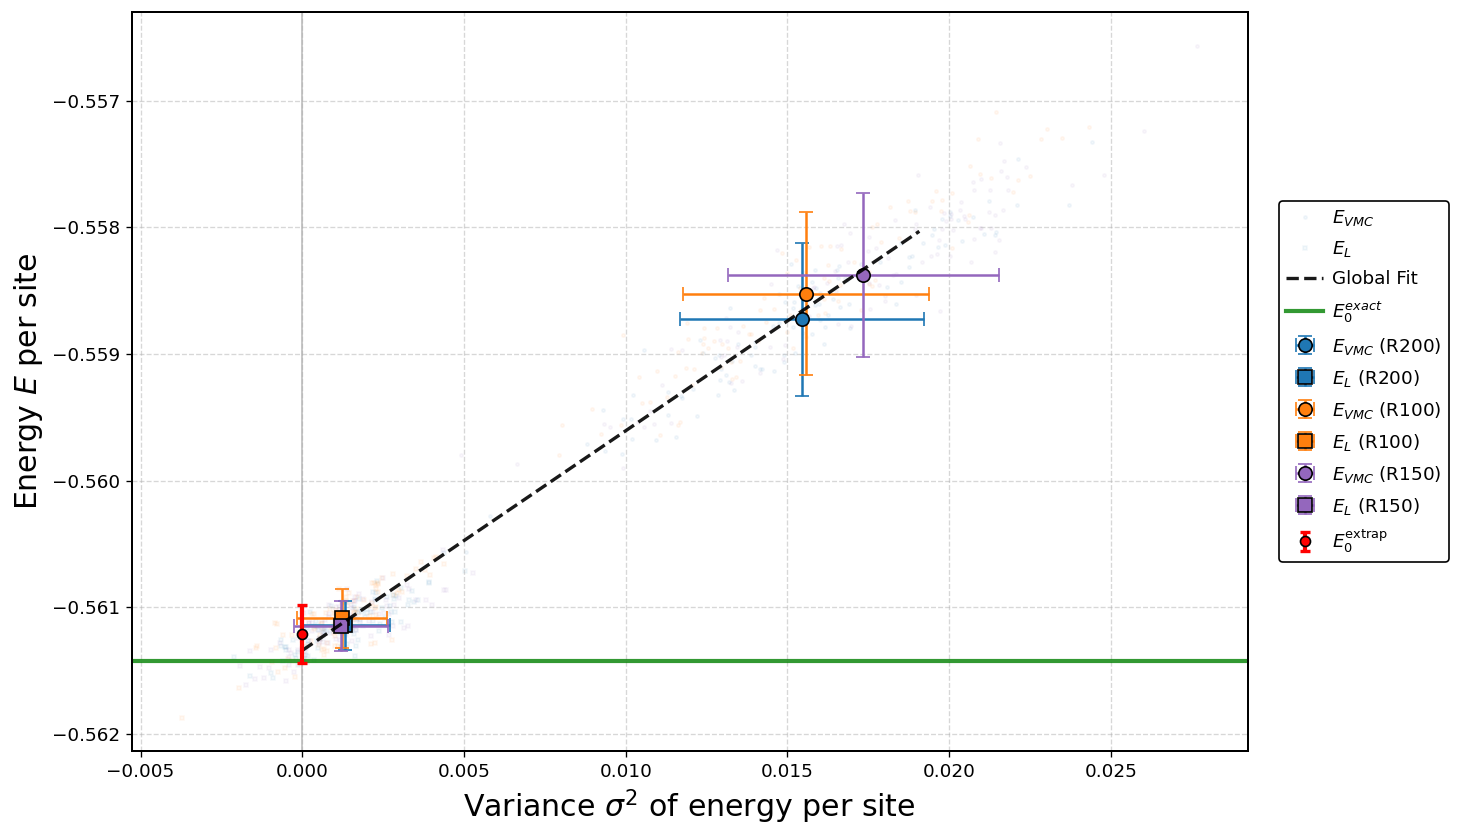

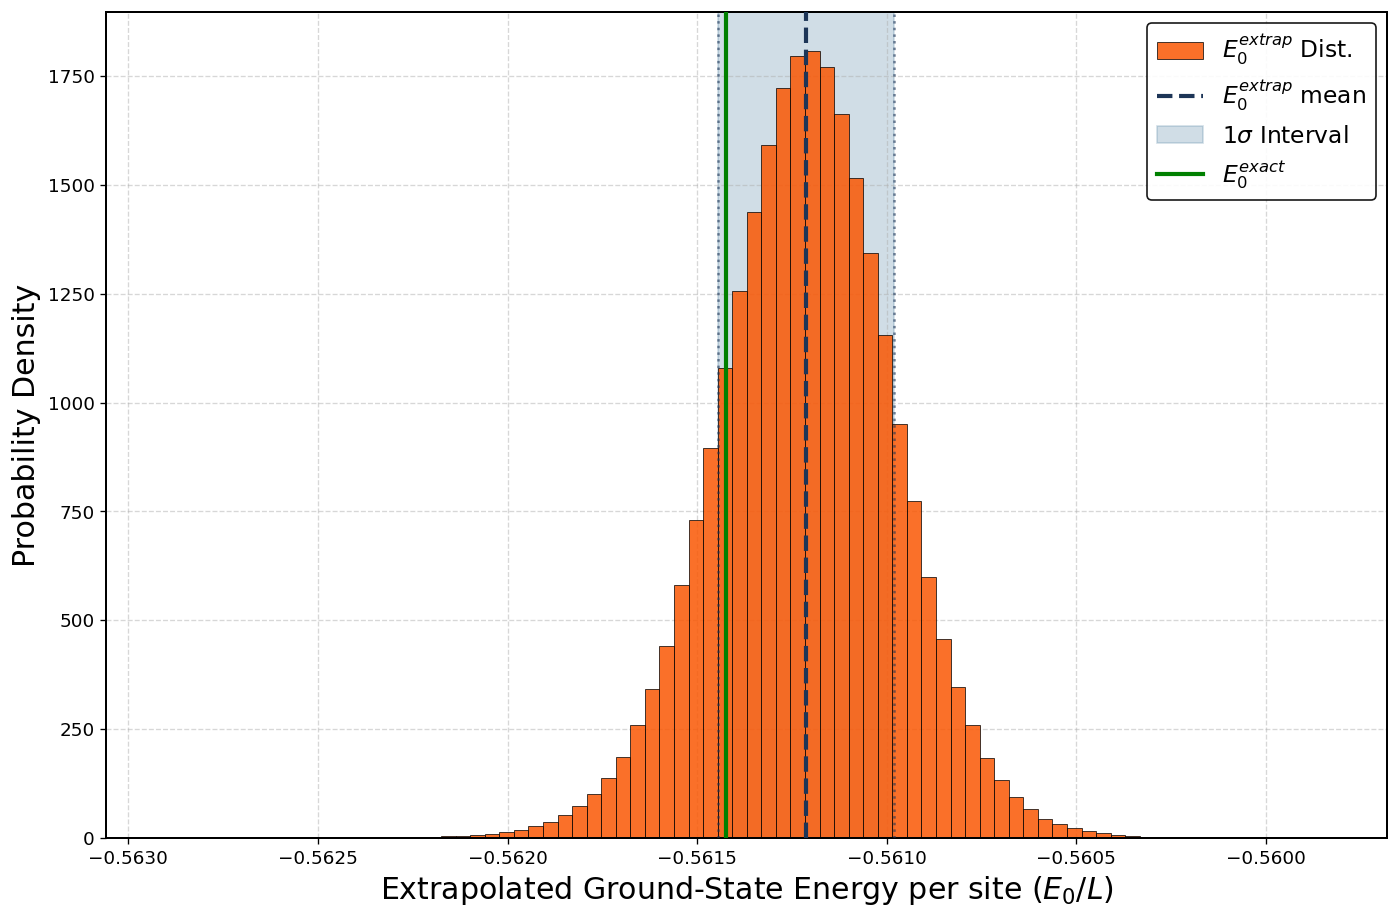

In [39]:
data_dict_AL = load_simulation_data(dossiers, L, verbose=True)
mc_results_AL = run_monte_carlo_extrapolation(data_dict_AL, N_sim, verbose=True)

plot_master_extrapolation(
    data_dict_AL, 
    mc_results_AL, 
    L, 
    save_dir="../../assets/2D_4x4", 
    name="AL_extrapolation_2d_hypercube"
)

plot_extrapolation_distribution(
    data_dict_AL, mc_results_AL, 
    save_dir="../../assets/2D_4x4", 
    name="AL_distribution_2d_hypercube"
)

In [40]:
df_results = create_results_table(data_dict_AL, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  var VMC  sem VMC  energy lanczos  var lanczos  sem lanczos
    100   -0.558522 0.015570 0.012478       -0.561089     0.001232     0.003510
    150   -0.558377 0.017342 0.013169       -0.561148     0.001190     0.003449
    200   -0.558726 0.015457 0.012433       -0.561145     0.001334     0.003652


## Krylov Subspace 

In [41]:
dossiers = glob.glob("../../datas/2D_4x4/datas_krylov_iter_*") 

Loading and processing 3 folders...
✅ Loading complete: 3 simulations processed!
Generating 1000000 synthetic linear regressions...

========== GLOBAL MONTE CARLO RESULTS ==========
Points used for fit       : 6 (3 simulations)
Exact Energy              : -0.56142416
Extrapolated Energy       : -0.56151609 ± 0.00070694
95% Confidence Interval   : [-0.56310206 , -0.56033934]
Absolute Error vs Exact   : 9.19e-05


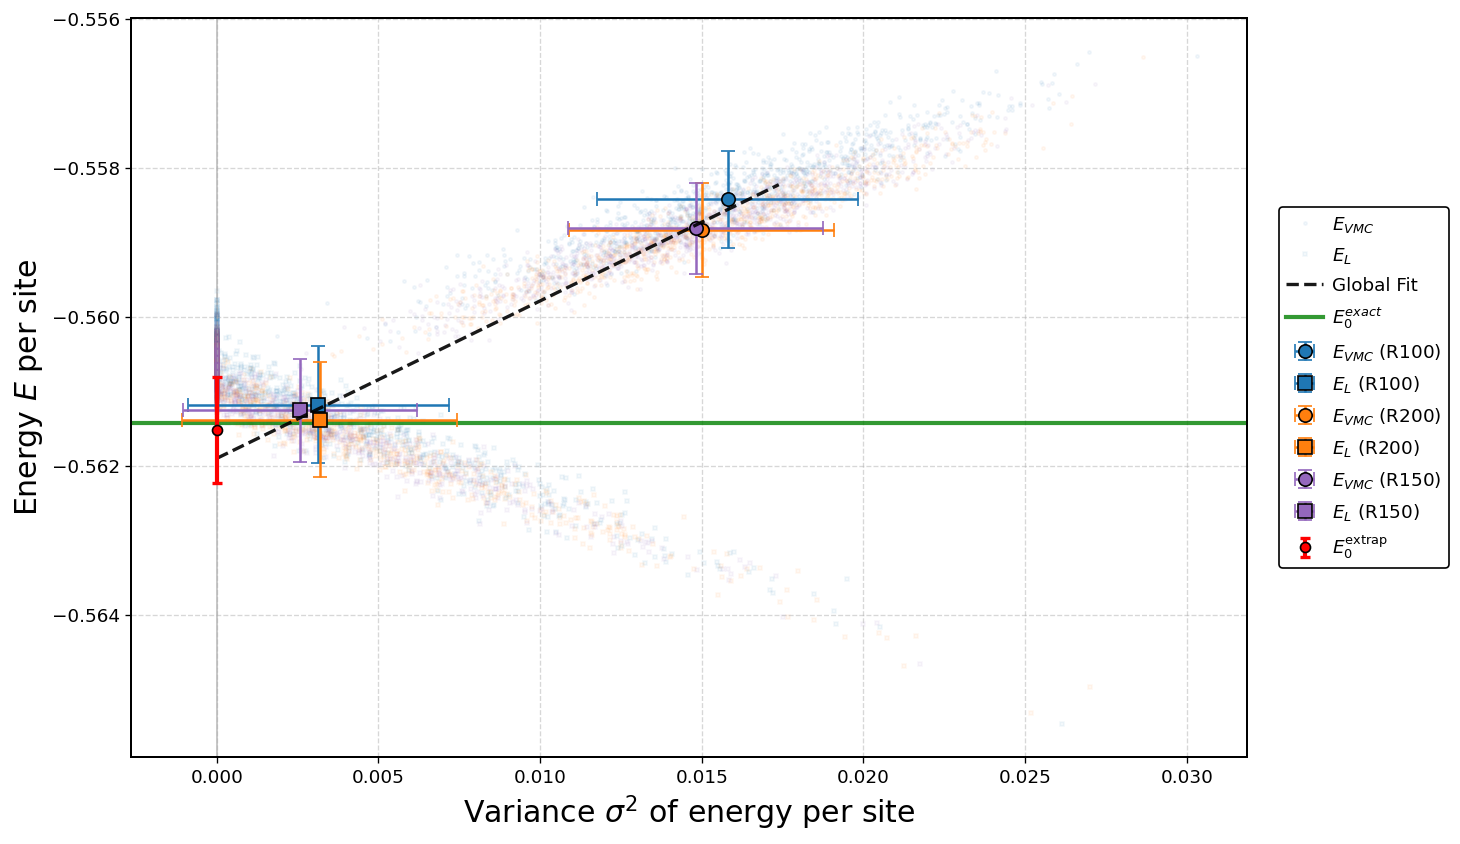

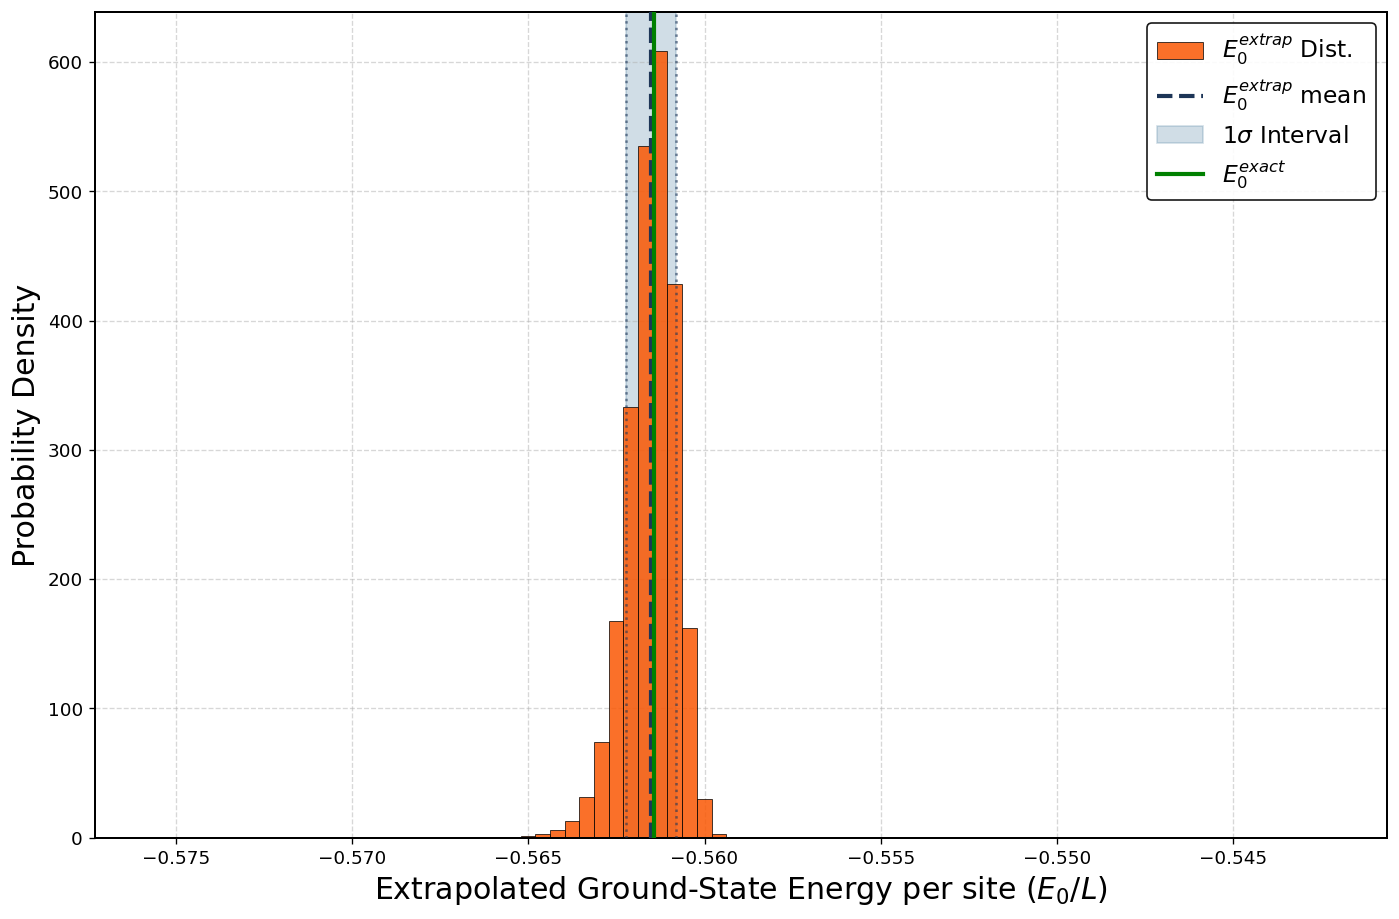

In [42]:
data_dict_KR = load_simulation_data(dossiers, L, verbose=True)
mc_results_KR = run_monte_carlo_extrapolation(data_dict_KR, N_sim, verbose=True)

plot_master_extrapolation(data_dict_KR, mc_results_KR, L, save_dir="../../assets/2D_4x4", name="Krylov_extrapolation_2d_hypercube")
plot_extrapolation_distribution(data_dict_KR, mc_results_KR, save_dir="../../assets/2D_4x4", name="Krylov_distribution_2d_hypercube")

In [43]:
df_results = create_results_table(data_dict_KR, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  var VMC  sem VMC  energy lanczos  var lanczos  sem lanczos
    100   -0.558417 0.015802 0.003975       -0.561175     0.003142     0.001773
    150   -0.558807 0.014809 0.003848       -0.561251     0.002569     0.001603
    200   -0.558834 0.014997 0.003873       -0.561376     0.003179     0.001783


## Comparaison 

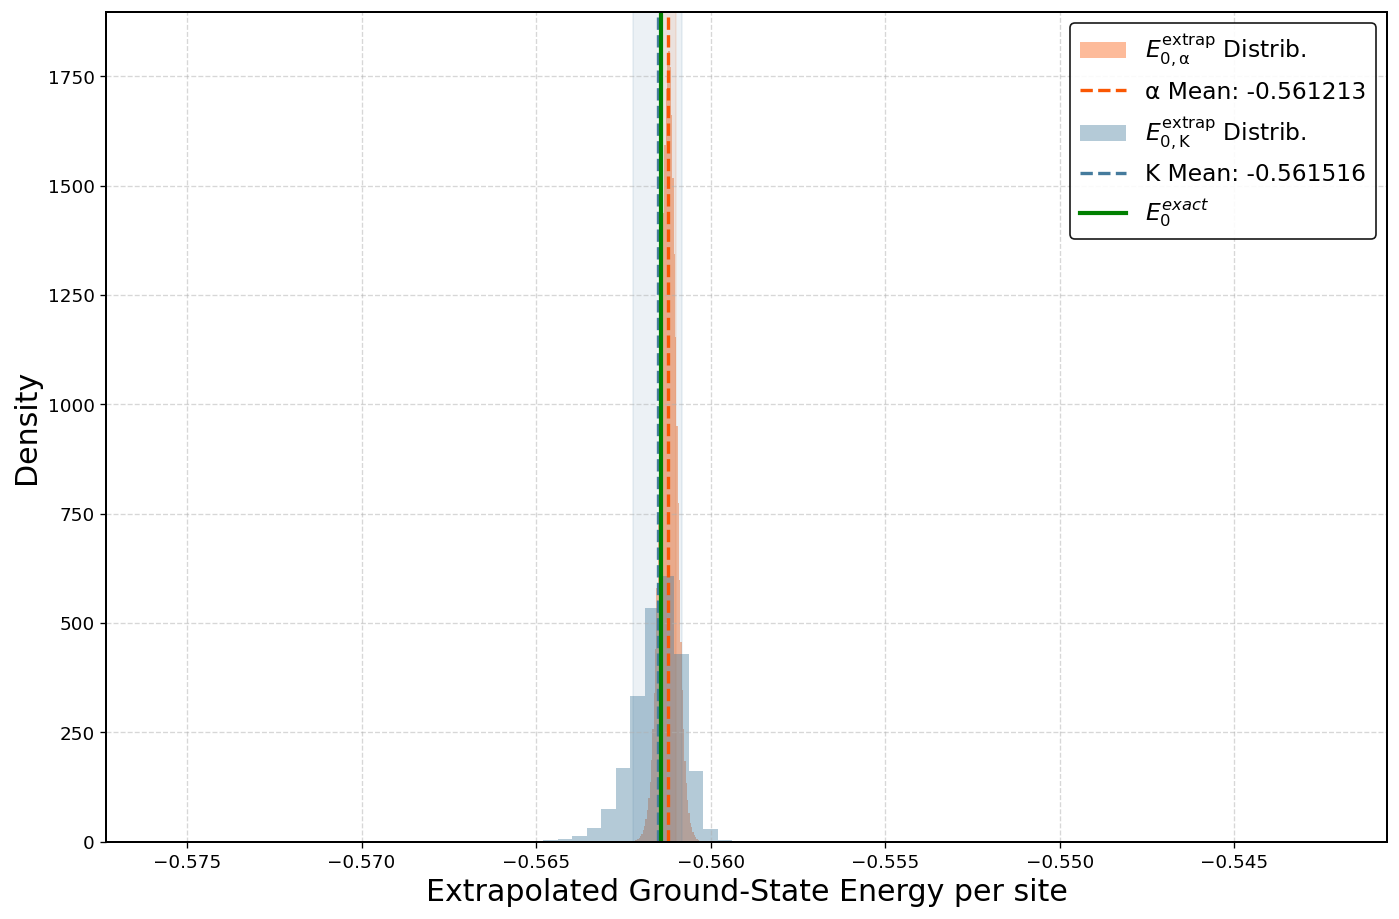

In [44]:
mes_distributions = {
    "α": mc_results_AL,
    "K": mc_results_KR
}

E_exacte = data_dict_AL["exact_gs_energy_per_site"]
plot_multiple_extrapolation_distributions(mes_distributions, E_exacte, save_dir="../../assets/2D_4x4")